In [21]:
import warnings
warnings.filterwarnings("ignore")

In [22]:

import tensorflow as tf
import os

import numpy as np
import matplotlib.pyplot as plt
import cv2

##  env check

In [23]:
# List all physical GPU devices detected by TensorFlow
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))
print(gpus)


# Verify if TensorFlow was built with CUDA support
print("Built with CUDA:", tf.test.is_built_with_cuda())

Num GPUs Available:  1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Built with CUDA: True


# Inference and Visualization

> model loading (keras format):

In [24]:
# Define the exact path where your models are saved
model_dir = 'mfsr_models/'
gen_model_name = 'MFSR_generator_v5.keras'
disc_model_name = 'MFSR_discriminator_v5.keras'


In [25]:

gen_load_path = os.path.join(model_dir, gen_model_name)
disc_load_path = os.path.join(model_dir, disc_model_name)

print(f"Loading the Generator model from: {gen_load_path} ...")
# Load the models with compile=False for inference
loaded_generator = tf.keras.models.load_model(gen_load_path, compile=False)

print(f"Loading the Discriminator model from: {disc_load_path} ...")
loaded_discriminator = tf.keras.models.load_model(disc_load_path, compile=False)

print("Models successfully loaded and ready for inference!")


Loading the Generator model from: mfsr_models/MFSR_generator_v5.keras ...
Loading the Discriminator model from: mfsr_models/MFSR_discriminator_v5.keras ...
Models successfully loaded and ready for inference!


In [26]:

# Optional: Print the model summary just to verify the architecture loaded correctly
loaded_generator.summary()
loaded_discriminator.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 128, 128,  │      3,072 │ input_layer[0][0] │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 64, 64,    │    131,584 │ sequential[0][0]  │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 32, 32,    │    525,312 │ sequential_1[0][… │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 16, 16,    │  2,099,200 │ sequential_2[0][… │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_4        │ (None, 8, 8, 512) │  4,196,352 │ sequential_3[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_5        │ (None, 4, 4, 512) │  4,196,352 │ sequential_4[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_6        │ (None, 2, 2, 512) │  4,196,352 │ sequential_5[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_7        │ (None, 4, 4, 512) │  4,196,352 │ sequential_6[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 4, 4,      │          0 │ sequential_7[0][… │
│ (Concatenate)       │ 1024)             │            │ sequential_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_8        │ (None, 8, 8, 512) │  8,390,656 │ concatenate[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 8, 8,      │          0 │ sequential_8[0][… │
│ (Concatenate)       │ 1024)             │            │ sequential_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_9        │ (None, 16, 16,    │  8,390,656 │ concatenate_1[0]… │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 16, 16,    │          0 │ sequential_9[0][… │
│ (Concatenate)       │ 1024)             │            │ sequential_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_10       │ (None, 32, 32,    │  4,195,328 │ concatenate_2[0]… │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 32, 32,    │          0 │ sequential_10[0]… │
│ (Concatenate)       │ 512)              │            │ sequential_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_11       │ (None, 64, 64,    │  1,049,088 │ concatenate_3[0]

 Total params: 41,838,851 (159.60 MB)

 Trainable params: 41,830,019 (159.57 MB)

 Non-trainable params: 8,832 (34.50 KB)

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ target_image        │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 256, 256,  │          0 │ input_image[0][0… │
│ (Concatenate)       │ 6)                │            │ target_image[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_13       │ (None, 128, 128,  │      6,144 │ concatenate_6[0]… │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_14       │ (None, 64, 64,    │    131,584 │ sequential_13[0]… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_15       │ (None, 32, 32,    │    525,312 │ sequential_14[0]… │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 34, 34,    │          0 │ sequential_15[0]… │
│ (ZeroPadding2D)     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 31, 31,    │  2,097,152 │ zero_padding2d[0… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 31,    │      2,048 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_10      │ (None, 31, 31,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 33, 33,    │          0 │ leaky_re_lu_10[0… │
│ (ZeroPadding2D)     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 30, 30, 1) │      8,193 │ zero_padding2d_1… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,770,433 (10.57 MB)

 Trainable params: 2,768,641 (10.56 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [27]:
def generate_and_plot_images(generator, discriminator, test_input, target=None, save_path=None, fig_title=None):
    # 1. Generate the unmasked face
    prediction = generator(test_input, training=False)
    
    # 2. Ask the discriminator to evaluate the GENERATED image
    # Note: PatchGAN takes [condition_image, target_image]
    disc_logits = discriminator([test_input, prediction], training=False)
    
    # 3. Convert raw logits to probabilities (0.0 = Fake, 1.0 = Real)
    heatmap_probs = tf.sigmoid(disc_logits[0]) 
    heatmap_2d = tf.squeeze(heatmap_probs) # Remove the channel dimension so it becomes a 30x30 2D array
    
    # Handle missing target
    if target is None:
        # Create a black image tensor of the same shape as prediction (filled with -1.0 for denormalization to 0)
        target_img = tf.fill(tf.shape(prediction[0]), -1.0)
    else:
        target_img = target[0]
        
    # Take the first image in the batch (index 0)
    display_list = [test_input[0], prediction[0], target_img]
    titles = ['Masked Input', 'Model Result', 'Ground Truth', 'PatchGAN Heatmap\n(Red=Fake, Green=Real)']
    
    # Increased width from 15 to 20 to comfortably fit 4 subplots
    plt.figure(figsize=(20, 5))
    
    # Add a main title for the entire figure if provided
    if fig_title:
        plt.suptitle(fig_title, fontsize=18, fontweight='bold', y=1.05)
    
    # Plot the 3 standard images
    for i in range(3):
        plt.subplot(1, 4, i+1)
        plt.title(titles[i], fontsize=14)
        
        # Denormalize the image from [-1, 1] to [0, 1] for matplotlib
        img = display_list[i] * 0.5 + 0.5
        
        plt.imshow(img)
        plt.axis('off')
        
    # Plot the 4th image: The Discriminator Heatmap
    plt.subplot(1, 4, 4)
    plt.title(titles[3], fontsize=14)
    # RdYlGn colormap forces 0 to be Red and 1 to be Green
    im = plt.imshow(heatmap_2d, cmap='RdYlGn', vmin=0, vmax=1)
    plt.axis('off')
    # Add a colorbar next to the heatmap to show the scale
    plt.colorbar(im, fraction=0.046, pad=0.04)
        
    plt.tight_layout()
    
    # Save the combined plot
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"Model successfully saved to: {save_path}")

    plt.show()
        
    plt.close() # Free up memory inside the Kaggle environment

In [28]:
def load_and_preprocess_image(image_path, img_height=256, img_width=256):
    """Loads a single image, resizes, normalizes to [-1, 1], and adds a batch dimension."""
    # Read the file from the given path
    img = tf.io.read_file(image_path)
    
    # Decode the image into a tensor (supports PNG, JPEG, etc.)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    
    # Resize to match the generator's expected input shape
    img = tf.cast(tf.image.resize(img, [img_height, img_width]), tf.float32)
    
    # Normalize pixel values to [-1, 1]
    img = (img / 127.5) - 1.0
    
    # Add a batch dimension: changes shape from (256, 256, 3) to (1, 256, 256, 3)
    img = tf.expand_dims(img, axis=0) 
    
    return img

def infer_on_custom_images(generator, input_path, discriminator=None, target_path=None, save_target_path=None):
    """Runs the model on specific input and target paths and plots results."""
    
    # Process the specific images
    test_input = load_and_preprocess_image(input_path)
    
    if target_path is not None:
        target = load_and_preprocess_image(target_path)
        print(f"Running inference on:\n - Input: {input_path}\n - Target: {target_path}")
    else:
        target = None
        print(f"Running inference on:\n - Input: {input_path}\n - Target: None")
    
    # Call your existing upgraded generate_and_plot_images function
    # Note: Using loaded_generator and loaded_discriminator from your previous cells
    generate_and_plot_images(
        generator=generator, 
        discriminator=discriminator, 
        test_input=test_input, 
        target=target, 
        save_path=save_target_path, 
        fig_title="Inference on Custom Image Pair"
    )

Running inference on:
 - Input: custom_images/test.png
 - Target: None


Model successfully saved to: custom_images/test_inference.png


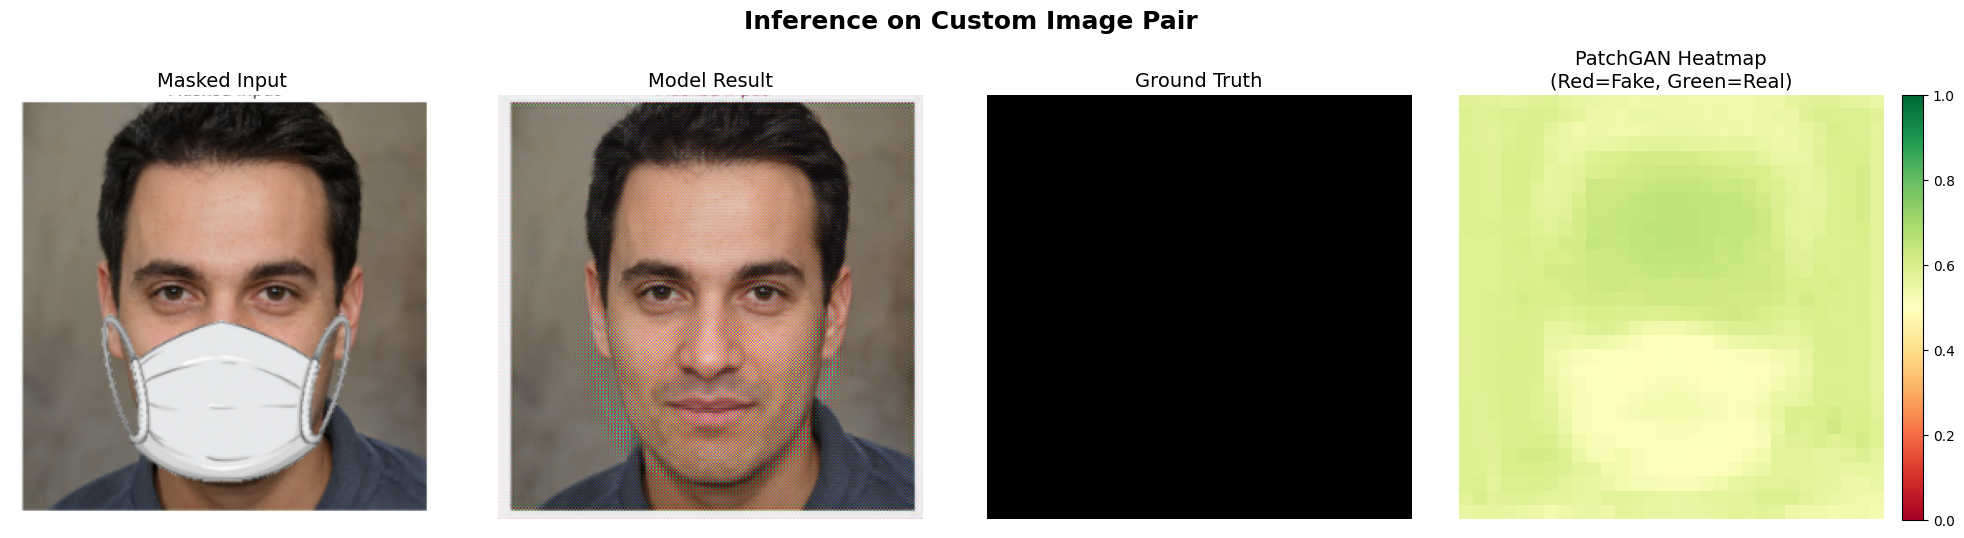

In [29]:
# ==========================================
# Example Usage:
# ==========================================
# Provide the absolute or relative paths to your specific files here
custom_masked_path = "custom_images/test.png"
custom_unmasked_path = "custom_images/test.png"
custom_save_path = "custom_images/test_inference.png" 

# ==========================================
# Run it using the models  loaded 

# tager path is optional
# ==========================================
infer_on_custom_images(
    generator=loaded_generator,
    input_path=custom_masked_path,
    discriminator=loaded_discriminator,
    # target_path=custom_unmasked_path,
    save_target_path=custom_save_path
)
